# 7. Spin polarization: LSDA

Every calculation so far has assumed that the spin-up and spin-down electrons have the
same density. That is exactly true for a closed-shell system and badly wrong for a
magnetic one: the whole of iron, cobalt and nickel's magnetism, and every open-shell
atom's, lives in the difference between the two.

The **local spin density approximation** is the smallest change that captures it. The
density becomes a pair,

    rho_up(r),  rho_dw(r),

and the two channels are diagonalised against *different* potentials. Which parts of the
energy split and which do not is the whole content of the approximation:

- **Hartree does not split.** An electron is repelled by charge, not by spin, so
  `V_H` is a functional of `rho_up + rho_dw` alone and is the same in both channels.
- **The kinetic and external terms do not split** either -- the same plane waves, the
  same pseudopotential.
- **Exchange and correlation do.** Two electrons of the same spin avoid each other for a
  reason that has nothing to do with their charge, and `e_xc` is a function of the
  polarization

      zeta = (rho_up - rho_dw) / rho

  as well as of the density.

So the one asymmetry above is what makes a magnetic ground state possible at all. This
notebook covers:

1. what the functional does with `zeta`, and where the polarized pieces come from;
2. an oxygen atom, where the occupations are fixed by hand and the magnetization is an
   input -- the cleanest possible test of the plumbing;
3. **nickel**, where the magnetization is an *output*: its moment, the exchange splitting
   of its d bands, and both against Quantum ESPRESSO;
4. the trap in the Fermi search that only a spin-polarized metal exposes;
5. constraining the magnetization, which needs two Fermi levels.

It needs the vendored QE tree for the input files; the reference outputs are committed
under `tests/data/qe/` (regenerated with the vendored `pw.x` at `conv_thr = 1e-10`, since
the benchmarks QE ships stop at 1e-6 and their printed energy *terms* are only good to
about 1e-4 Ry).

In [1]:
from pathlib import Path

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from pypresso.io import read_qe_output
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.system import build_system
from pypresso.system.kpoints import KPoints
from pypresso.units import RY_TO_EV
from pypresso.workflows import run_bands
from pypresso.xc.functional import get_functional

SUITE = Path('../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite')
REFERENCE = Path('../tests/data/qe')
PSEUDO = Path('../tests/data/pseudo')


def load(directory, name):
    pwin = read_pw_input(SUITE / directory / name)
    system = build_system(pwin)
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    beta = float(pwin.get('electrons', 'mixing_beta', 0.7))
    return system, pseudos, beta


def qe(directory, name):
    return read_qe_output(REFERENCE / f'reference.out.{directory}-{Path(name).stem}')

## 1. What the functional does with the polarization

Exchange needs no new formula at all. It obeys an exact **spin-scaling relation**

    E_x[rho_up, rho_dw] = ( E_x[2 rho_up] + E_x[2 rho_dw] ) / 2,

which says that same-spin exchange is the unpolarized functional evaluated on a gas of
twice the density, once per channel. QE uses it directly -- `gcx_spin` doubles each
channel's density (and quadruples its `|grad rho|^2`) and calls the *unpolarized*
routine -- and so does this code, which is why there is no table of polarized exchange
functionals anywhere in `pypresso.xc`.

Correlation has no such relation. The polarized limit is a separate fit to the same Monte
Carlo data, and what interpolates between the two is

    f(zeta) = ((1+zeta)^(4/3) + (1-zeta)^(4/3) - 2) / (2^(4/3) - 2),

the ratio of the non-interacting kinetic energies -- zero unpolarized, one fully
polarized. Below: the exchange and correlation energy per electron at a fixed density, as
the polarization is turned up.

exchange   zeta=0:  -7.4039 eV   zeta=1:  -9.3283 eV   ratio 1.259921  (2^(1/3) = 1.259921)
correlation zeta=0:  -1.3226 eV   zeta=1:  -0.7050 eV


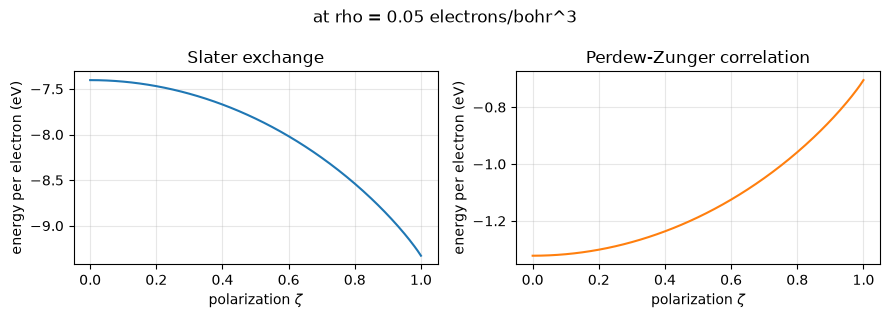

In [2]:
PZ = get_functional('PZ')
zeta = jnp.linspace(0.0, 1.0, 201)
rho = 0.05  # electrons/bohr^3, a typical bonding density

pair = jnp.stack([0.5 * rho * (1 + zeta), 0.5 * rho * (1 - zeta)])
exchange = np.asarray(
    (pair[0] * PZ.exchange(2 * pair[0]) + pair[1] * PZ.exchange(2 * pair[1])) / rho
)
correlation = np.asarray(PZ.correlation_spin(jnp.full_like(zeta, rho), zeta))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
axes[0].plot(zeta, exchange * RY_TO_EV)
axes[0].set_title('Slater exchange')
axes[1].plot(zeta, correlation * RY_TO_EV, color='C1')
axes[1].set_title('Perdew-Zunger correlation')
for ax in axes:
    ax.set_xlabel(r'polarization $\zeta$')
    ax.set_ylabel('energy per electron (eV)')
    ax.grid(alpha=0.3)
fig.suptitle(f'at rho = {rho} electrons/bohr^3')
fig.tight_layout()

print(f'exchange   zeta=0: {exchange[0] * RY_TO_EV:8.4f} eV   zeta=1: {exchange[-1] * RY_TO_EV:8.4f} eV'
      f'   ratio {exchange[-1] / exchange[0]:.6f}  (2^(1/3) = {2 ** (1/3):.6f})')
print(f'correlation zeta=0: {correlation[0] * RY_TO_EV:8.4f} eV   zeta=1: {correlation[-1] * RY_TO_EV:8.4f} eV')

The exchange ratio is exactly `2^(1/3)`, which is the spin-scaling relation for a Slater
functional written out: fully polarizing the gas at fixed total density doubles the
density each channel's exchange sees, and Slater exchange goes as `rho^(1/3)`. Exchange
*gains* by polarizing; correlation loses less than exchange gains, and the balance of the
two is what decides whether a material is magnetic.

**Only the energy is written down.** The potentials `v_up` and `v_dw` -- which QE derives
by hand, `slater_spin` returning two and `pz_spin` three terms each including an explicit
`df/dzeta` -- are `jax.grad` of that energy with respect to the two channel densities.
The test suite checks them against QE's algebra transcribed independently; they agree to
1.3e-15.

In [3]:
# v_xc for a polarized density: two numbers where an unpolarized calculation has one.
density = jnp.stack([jnp.full((3,), 0.04), jnp.full((3,), 0.01)])
v_up, v_dw = np.asarray(PZ.spin_potential(density))
print(f'rho_up = 0.04, rho_dw = 0.01  ->  v_up = {v_up[0]:.6f} Ry, v_dw = {v_dw[0]:.6f} Ry')
print(f'                                  splitting = {(v_dw[0] - v_up[0]) * RY_TO_EV:.4f} eV')

# ... and it collapses to the unpolarized potential when the channels are equal.
equal = jnp.stack([jnp.full((3,), 0.025)] * 2)
print('unpolarized check:', np.asarray(PZ.spin_potential(equal))[:, 0],
      float(PZ.potential(jnp.full((3,), 0.05))[0]))

rho_up = 0.04, rho_dw = 0.01  ->  v_up = -0.922834 Ry, v_dw = -0.709592 Ry
                                  splitting = 2.9013 eV
unpolarized check: [-0.83655011 -0.83655011] -0.836550107949976


## 2. An oxygen atom, with the occupations fixed by hand

`test-suite/pw_atom/atom-lsda.in` is the smallest useful spin-polarized calculation: one
oxygen atom in a 10-bohr box, at Gamma, with `occupations='from_input'` giving the
filling of each channel explicitly --

    up:   1  1  1  1  0  0
    down: 1  .333 .333 .333  0  0

Six electrons, four in the majority channel and two in the minority: a magnetization of
exactly 2 Bohr magnetons, fixed by the input rather than found by the calculation. That is
what makes it the right first test -- there is no Fermi search at all, so what it
exercises is the spin plumbing and nothing else.

In [4]:
system, pseudos, beta = load('pw_atom', 'atom-lsda.in')
oxygen = run_scf(system, pseudos, conv_thr=1e-10, max_iterations=200, mixing_beta=beta)
reference = qe('pw_atom', 'atom-lsda.in')

print(f'converged in {oxygen.iterations} iterations')
print(f'total energy      {oxygen.total_energy:.9f} Ry   QE {reference.total_energy:.8f} Ry'
      f'   difference {abs(oxygen.total_energy - reference.total_energy):.1e}')
print(f'magnetization     {oxygen.magnetization:.6f} mu_B   QE {reference.magnetization}')
print(f'absolute          {oxygen.absolute_magnetization:.6f} mu_B   QE {reference.absolute_magnetization}')

/u/40/ladovj1/data/Documents/programs/claude/pypresso/.claude/worktrees/agent-af370df4431de471d/pypresso/scf/driver.py:923: UserWarning: K_POINTS gamma asks for the half-sphere storage of the gamma-point trick, which is not implemented; running at an explicit k = 0 with the full G sphere instead. The result is the same, the cost is twice the plane waves
  calculation = calculation or Calculation(system, pseudos, diagonalization=diagonalization)


converged in 12 iterations
total energy      -31.404683565 Ry   QE -31.40468356 Ry   difference 4.8e-09
magnetization     2.000000 mu_B   QE 2.0
absolute          2.000206 mu_B   QE 2.0


In [5]:
levels = oxygen.eigenvalues_by_spin[:, 0, :] * RY_TO_EV
theirs = reference.eigenvalues[:, 0, :]
print('        ' + ''.join(f'{i:>10d}' for i in range(levels.shape[1])))
for spin, label in enumerate(['up  ', 'down']):
    print(f'{label}    ' + ''.join(f'{e:10.4f}' for e in levels[spin]))
    print('  (QE) ' + ''.join(f'{e:10.4f}' for e in theirs[spin]))
print()
print(f'2s exchange splitting: {levels[1, 0] - levels[0, 0]:.4f} eV')
print(f'2p exchange splitting: {levels[1, 1] - levels[0, 1]:.4f} eV')

                 0         1         2         3         4         5
up        -24.3326   -9.6440   -9.6440   -9.6440   -0.4665    4.4702
  (QE)   -24.3325   -9.6439   -9.6439   -9.6439   -0.4658    4.4721
down      -21.1133   -6.6339   -6.6339   -6.6339   -0.3227    4.5399
  (QE)   -21.1132   -6.6338   -6.6338   -6.6338   -0.3196    4.5435

2s exchange splitting: 3.2192 eV
2p exchange splitting: 3.0101 eV


The majority levels sit about 3 eV below the minority ones. That gap is the **exchange
splitting**, and it is not a small correction bolted onto an unpolarized answer: it is the
difference between the two potentials the two channels were diagonalised against, and it
is why the atom is magnetic.

(The two empty levels above the four occupied ones are diffuse states of the periodic box
rather than atomic states, and QE interpolates its local potential from a `dq = 0.01`
table where this code integrates directly -- a difference that averages out over a bound
state's many plane waves and does not over a state spread across the whole cell. They
carry no weight in the density.)

## 3. Nickel: the magnetization as an output

Now the case the approximation exists for. `test-suite/pw_lsda/lsda.in` is fcc nickel with
Marzari-Vanderbilt smearing on a 4x4x4 grid. Nothing fixes the magnetization: the two
channels share **one Fermi level**, the d bands shift relative to each other until the
energy stops falling, and how many electrons end up in each channel is whatever that
balance gives.

The only thing the input says about magnetism is `starting_magnetization = 0.7`, which
splits the superposition of atomic charges the SCF starts from. That is not a constraint
-- it is a *seed*, and it is needed because nothing else in the calculation breaks the
spin symmetry: with the two channels started identical they stay identical, and the run
converges to the unpolarized solution, which is always a stationary point.

In [6]:
system, pseudos, beta = load('pw_lsda', 'lsda.in')
nickel = run_scf(system, pseudos, conv_thr=1e-10, max_iterations=200, mixing_beta=beta)
reference = qe('pw_lsda', 'lsda.in')

print(f'converged in {nickel.iterations} iterations, {system.kpoints.nk} k-points per channel')
print(f'total energy      {nickel.total_energy:.9f} Ry   QE {reference.total_energy:.8f} Ry'
      f'   difference {abs(nickel.total_energy - reference.total_energy):.1e}')
print(f'Fermi energy      {nickel.fermi_energy * RY_TO_EV:.4f} eV   QE {reference.fermi_energy:.4f} eV')
print(f'magnetization     {nickel.magnetization:.4f} mu_B   QE {reference.magnetization}')
print(f'absolute          {nickel.absolute_magnetization:.4f} mu_B   QE {reference.absolute_magnetization}')

converged in 13 iterations, 10 k-points per channel
total energy      -85.723399012 Ry   QE -85.72339901 Ry   difference 1.9e-09
Fermi energy      15.3088 eV   QE 15.3088 eV
magnetization     0.7280 mu_B   QE 0.73
absolute          0.7842 mu_B   QE 0.78


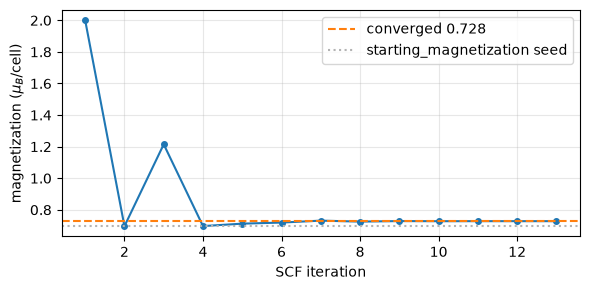

In [7]:
history = np.array([[h['iteration'], h['magnetization']] for h in nickel.history])
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history[:, 0], history[:, 1], 'o-', ms=4)
ax.axhline(nickel.magnetization, color='C1', ls='--', label=f'converged {nickel.magnetization:.3f}')
ax.axhline(0.7 * 10 / 10, color='0.7', ls=':', label='starting_magnetization seed')
ax.set_xlabel('SCF iteration')
ax.set_ylabel(r'magnetization ($\mu_B$/cell)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

The seed puts about two Bohr magnetons on the atom; the SCF takes them away again and
settles at 0.73, which is the experimental moment of nickel to within the usual LSDA
underestimate. **Nothing about the calculation was told to do that** -- it is what
minimising the energy over both channels gives.

### The exchange splitting of the d bands

The moment is the integral of the difference between the two channels' densities. Where it
comes from is visible in the bands: nickel's majority d bands are pulled below the Fermi
level and its minority d bands straddle it, and the gap between them is the exchange
splitting.

In [8]:
# A band structure at fixed density, on the standard fcc path W - L - Gamma - X - W - K.
path = np.array([[0.5, 0.25, 0.75], [0.5, 0.5, 0.5], [0.0, 0.0, 0.0],
                 [0.0, 0.0, 1.0], [0.5, 0.25, 0.75], [0.375, 0.375, 0.75]])
counts = np.array([12, 16, 16, 12, 8, 0])
labels = ['W', 'L', r'$\Gamma$', 'X', 'W', 'K']

bands = run_bands(
    system, pseudos, nickel.density,
    kpoints=KPoints.band_path(path, counts, system.cell, crystal=False),
    nbnd=9, conv_thr=1e-10,
    fermi_energy=nickel.fermi_energy,
)
print('bands', bands.eigenvalues_by_spin.shape)

bands (2, 65, 9)


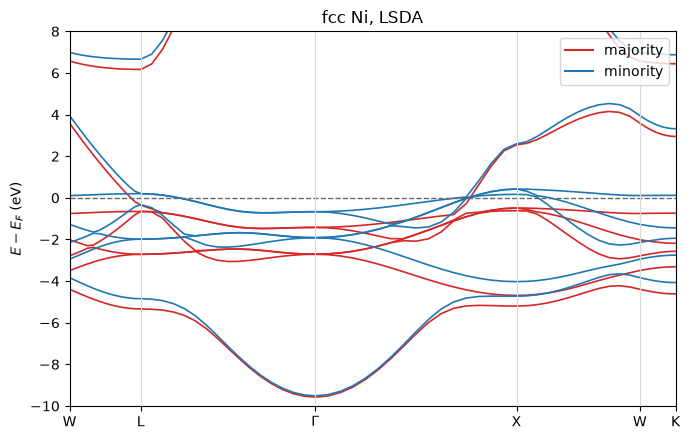

In [9]:
x = bands.path_length
ef = nickel.fermi_energy * RY_TO_EV
levels = bands.eigenvalues_by_spin * RY_TO_EV - ef

fig, ax = plt.subplots(figsize=(7, 4.5))
for spin, (colour, label) in enumerate([('C3', 'majority'), ('C0', 'minority')]):
    ax.plot(x, levels[spin], color=colour, lw=1.2)
    ax.plot([], [], color=colour, label=label)
ax.axhline(0.0, color='0.4', ls='--', lw=1)
ticks = [x[i] for i in np.cumsum([0] + list(counts[:-1]))]
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
for t in ticks:
    ax.axvline(t, color='0.85', lw=0.8)
ax.set_xlim(x[0], x[-1])
ax.set_ylim(-10, 8)
ax.set_ylabel(r'$E - E_F$ (eV)')
ax.set_title('fcc Ni, LSDA')
ax.legend(loc='upper right')
fig.tight_layout()

In [10]:
# The splitting itself, band by band, at Gamma and averaged over the d manifold.
gamma = int(np.argmin(np.linalg.norm(np.asarray(bands.kpoints.coords), axis=1)))
at_gamma = bands.eigenvalues_by_spin[:, gamma, :] * RY_TO_EV
print(f'at Gamma (band index, majority, minority, splitting) in eV:')
for n in range(6):
    print(f'  {n}   {at_gamma[0, n]:9.4f}  {at_gamma[1, n]:9.4f}   {at_gamma[1, n] - at_gamma[0, n]:7.4f}')

d_bands = slice(1, 6)  # the five d bands
splitting = float(np.mean(
    bands.eigenvalues_by_spin[1, :, d_bands] - bands.eigenvalues_by_spin[0, :, d_bands]
)) * RY_TO_EV
print(f'\nmean exchange splitting of the d manifold over the path: {splitting:.3f} eV')

at Gamma (band index, majority, minority, splitting) in eV:
  0      5.7337     5.7944    0.0608
  1     12.5976    13.3931    0.7955
  2     12.5976    13.3931    0.7955
  3     12.5976    13.3931    0.7955
  4     13.8878    14.6414    0.7536
  5     13.8878    14.6414    0.7536

mean exchange splitting of the d manifold over the path: 0.688 eV


About half an electronvolt, and it is the *cause* of the moment rather than a consequence:
the majority d states are pushed down far enough to be entirely below the Fermi level
while the minority ones are not, so the two channels hold different numbers of electrons.

## 4. The trap: the Fermi level of a smeared magnet

A cold-smeared occupation is not a monotonic function of energy. Marzari-Vanderbilt
smearing **overshoots** -- an occupation reaches 1.07 before settling back to 1 -- and
that is deliberate: the overshoot is what makes the free energy a better approximation to
the zero-temperature one than a Fermi-Dirac occupation of the same width. The price is
that the electron count

    N(E_F) = sum_k w_k sum_n f((E_F - e_nk)/degauss)

is not monotonic either, so `N(E_F) = nelec` can have **several roots**, and a plain
bisection lands on whichever one its bracket happens to select.

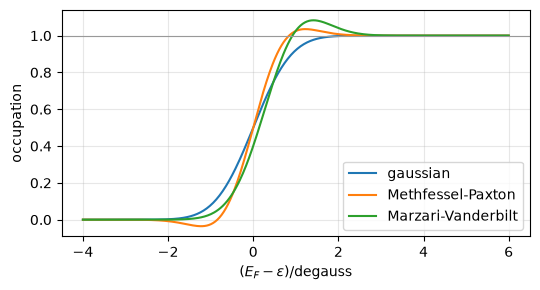

In [11]:
from pypresso.scf.occupations import wgauss

x = jnp.linspace(-4.0, 6.0, 400)
fig, ax = plt.subplots(figsize=(5.5, 3))
for ngauss, label in [(0, 'gaussian'), (1, 'Methfessel-Paxton'), (-1, 'Marzari-Vanderbilt')]:
    ax.plot(x, np.asarray(wgauss(x, ngauss)), label=label)
ax.axhline(1.0, color='0.6', lw=0.8)
ax.set_xlabel(r'$(E_F - \varepsilon)/\mathrm{degauss}$')
ax.set_ylabel('occupation')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

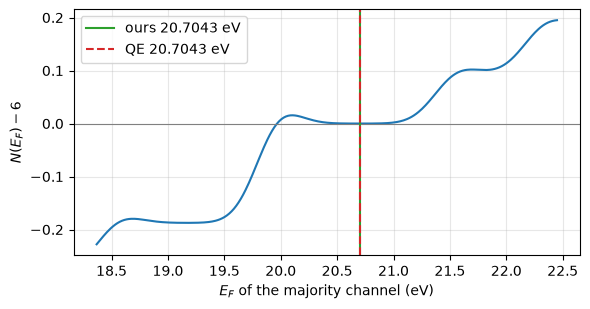

In [12]:
# Nickel with the magnetization constrained to 2 mu_B: the majority channel then holds
# six electrons and is nearly full, so its count function is nearly flat over an
# electronvolt -- and the overshoot makes it wobble across nelec more than once.
system_c, pseudos_c, beta_c = load('pw_lsda', 'lsda-tot_magnetization.in')
constrained = run_scf(system_c, pseudos_c, conv_thr=1e-10, max_iterations=200, mixing_beta=beta_c)
reference_c = qe('pw_lsda', 'lsda-tot_magnetization.in')

et = jnp.asarray(constrained.eigenvalues_by_spin[0])
wk = system_c.kpoints.weights
grid = jnp.linspace(1.35, 1.65, 400)
count = np.array([
    float(jnp.sum(wk[:, None] * wgauss((e - et) / system_c.degauss, -1))) for e in grid
])

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(grid * RY_TO_EV, count - 6.0)
ax.axhline(0.0, color='0.5', lw=0.8)
ax.axvline(constrained.fermi_energy_up * RY_TO_EV, color='C2',
           label=f'ours {constrained.fermi_energy_up * RY_TO_EV:.4f} eV')
ax.axvline(reference_c.fermi_energy_up, color='C3', ls='--',
           label=f'QE {reference_c.fermi_energy_up:.4f} eV')
ax.set_xlabel(r'$E_F$ of the majority channel (eV)')
ax.set_ylabel(r'$N(E_F) - 6$')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

The curve crosses zero more than once and is flat to within 1e-5 electrons over most of
the range. Every crossing gives the same density -- so the SCF converges just as happily
to any of them -- but **not** the same entropy: picking the wrong root leaves `-TS` out by
3e-4 Ry, and with it the total energy.

`efermig` in QE avoids this in a way worth transcribing rather than reinventing: it
bisects with a **Gaussian** smearing first, which is monotonic and has exactly one root,
and then refines that guess with Newton's method on the actual occupation function. The
Gaussian level selects the physical root; the refinement moves it to where the real count
is right. (Here Newton's first and second derivatives of the count come from `jax.grad`
of the count itself, where QE hand-writes `sumkg1` and `sumkg2` as separate sums.)

## 5. Constraining the magnetization

`tot_magnetization` fixes `N_up - N_dw` instead of letting the channels share a Fermi
level. Each channel then gets its own, solving for its own electron count, and the `-TS`
term is the sum of the two.

In [13]:
print(f'total energy      {constrained.total_energy:.9f} Ry   QE {reference_c.total_energy:.8f} Ry'
      f'   difference {abs(constrained.total_energy - reference_c.total_energy):.1e}')
print(f'Fermi (up)        {constrained.fermi_energy_up * RY_TO_EV:.4f} eV   QE {reference_c.fermi_energy_up:.4f} eV')
print(f'Fermi (down)      {constrained.fermi_energy_down * RY_TO_EV:.4f} eV   QE {reference_c.fermi_energy_down:.4f} eV')
print(f'magnetization     {constrained.magnetization:.6f} mu_B   QE {reference_c.magnetization}')
print(f'-TS               {constrained.energy_terms["smearing"]:.9f} Ry   '
      f'QE {reference_c.energy_terms["smearing"]:.8f} Ry')
print()
print(f'unconstrained nickel sat at {nickel.magnetization:.4f} mu_B and '
      f'{nickel.total_energy:.6f} Ry;')
print(f'forcing 2 mu_B costs {(constrained.total_energy - nickel.total_energy) * RY_TO_EV:.3f} eV.')

total energy      -85.578422231 Ry   QE -85.57842223 Ry   difference 1.2e-09
Fermi (up)        20.7043 eV   QE 20.7043 eV
Fermi (down)      14.2991 eV   QE 14.2991 eV
magnetization     2.000022 mu_B   QE 2.0
-TS               -0.000291352 Ry   QE -0.00029136 Ry

unconstrained nickel sat at 0.7280 mu_B and -85.723399 Ry;
forcing 2 mu_B costs 1.973 eV.


Forcing the moment up to 2 Bohr magnetons costs about two electronvolts, which is the
answer to "why is nickel's moment 0.7 and not 2": the majority d bands are already full at
0.7, and every further electron moved into them has to come out of the s band and go into
a minority d state well above the Fermi level.

## 6. PAW spheres get a spin index too

PAW recomputes the Hartree and exchange-correlation energy twice on each atom's own radial
mesh and adds the difference. With two channels the split is the same one the plane-wave
grid makes, for the same reason: `PAW_h_potential` **sums over spin** before solving the
radial Poisson equation and copies the single answer into both channels, while the
exchange-correlation pass runs per channel on the spherical quadrature.

The two spin-polarized PAW cases QE ships put the minority channel's electron into *one*
of the three 2p orbitals -- which is why they set `nosym` -- and that makes the state
nearly degenerate under which orbital it is. QE needs 71 iterations on them, fails to
converge at `mixing_beta = 0.3`, and moves its own answer by 6e-7 Ry between
`mixing_ndim = 8` and `4`. They are a fine test of *agreement* and a poor test of the
machinery, so the pair below spreads that electron evenly over the three instead. Same
dataset, same cell, same cutoff; only the conditioning changes.

In [14]:
def local(case):
    pwin = read_pw_input(REFERENCE / f'{case}.in')
    system_l = build_system(pwin)
    pseudos_l = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system_l.structure.species)
    beta_l = float(pwin.get('electrons', 'mixing_beta', 0.7))
    return system_l, pseudos_l, beta_l, read_qe_output(REFERENCE / f'reference.out.{case}')


paw = {}
for name in ('o-paw-spin', 'o-paw-spin-pbe'):
    system_p, pseudos_p, beta_p, ref_p = local(name)
    result = run_scf(system_p, pseudos_p, conv_thr=1e-10, max_iterations=200,
                     mixing_beta=beta_p)
    paw[name] = (result, ref_p)
    print(f'{name:16s} {result.iterations:3d} iterations   E = {result.total_energy:16.9f} Ry'
          f'   QE {ref_p.total_energy:14.8f}   diff {abs(result.total_energy - ref_p.total_energy):.1e}')
    print(f'{"":16s} one-centre {result.energy_terms["one_center_paw"]:15.9f} Ry'
          f'   QE {ref_p.energy_terms["one_center_paw"]:14.8f}'
          f'   m = {result.magnetization:.6f} mu_B')

/u/40/ladovj1/data/Documents/programs/claude/pypresso/.claude/worktrees/agent-af370df4431de471d/pypresso/scf/driver.py:923: UserWarning: K_POINTS gamma asks for the half-sphere storage of the gamma-point trick, which is not implemented; running at an explicit k = 0 with the full G sphere instead. The result is the same, the cost is twice the plane waves
  calculation = calculation or Calculation(system, pseudos, diagonalization=diagonalization)


o-paw-spin         9 iterations   E =    -40.237991292 Ry   QE   -40.23799149   diff 2.0e-07
                 one-centre    -9.255925104 Ry   QE    -9.25592929   m = 2.000000 mu_B


o-paw-spin-pbe     9 iterations   E =    -41.237590282 Ry   QE   -41.23759048   diff 2.0e-07
                 one-centre    -9.969080829 Ry   QE    -9.96908377   m = 2.000000 mu_B


The one-centre term is of the order of the total energy itself, so agreeing with it to a
few times 1e-6 Ry is a check on the radial machinery rather than on rounding.

## 7. Everything against Quantum ESPRESSO

In [15]:
rows = [('O atom, LDA, occupations from input', oxygen, qe('pw_atom', 'atom-lsda.in')),
        ('fcc Ni, one shared Fermi level', nickel, qe('pw_lsda', 'lsda.in')),
        ('fcc Ni, two Fermi levels', constrained,
         qe('pw_lsda', 'lsda-tot_magnetization.in'))]

for directory, name, description in [
    ('pw_lsda', 'lsda-nelup+neldw.in', 'fcc Ni, the constraint spelled 2.0'),
    ('pw_atom', 'atom-sigmapbe.in', 'O atom, spin-polarized PBE'),
]:
    system_i, pseudos_i, beta_i = load(directory, name)
    rows.append((description,
                 run_scf(system_i, pseudos_i, conv_thr=1e-10, max_iterations=300,
                         mixing_beta=beta_i),
                 qe(directory, name)))

rows += [('O atom, PAW + spin, LDA', *paw['o-paw-spin']),
         ('O atom, PAW + spin, PBE', *paw['o-paw-spin-pbe'])]

print(f'{"case":38s} {"pypresso (Ry)":>17s} {"QE (Ry)":>16s} {"diff":>9s}  {"m":>7s} {"QE":>5s}')
for description, result, ref in rows:
    print(f'{description:38s} {result.total_energy:17.9f} {ref.total_energy:16.8f} '
          f'{abs(result.total_energy - ref.total_energy):9.1e}'
          f'  {result.magnetization:7.4f} {ref.magnetization:5.2f}')

case                                       pypresso (Ry)          QE (Ry)      diff        m    QE
O atom, LDA, occupations from input        -31.404683565     -31.40468356   4.8e-09   2.0000  2.00
fcc Ni, one shared Fermi level             -85.723399012     -85.72339901   1.9e-09   0.7280  0.73
fcc Ni, two Fermi levels                   -85.578422231     -85.57842223   1.2e-09   2.0000  2.00
fcc Ni, the constraint spelled 2.0         -85.578422231     -85.57842223   1.2e-09   2.0000  2.00
O atom, spin-polarized PBE                 -31.491019388     -31.49101939   1.8e-09   2.0000  2.00
O atom, PAW + spin, LDA                    -40.237991292     -40.23799149   2.0e-07   2.0000  2.00
O atom, PAW + spin, PBE                    -41.237590282     -41.23759048   2.0e-07   2.0000  2.00


The two broken-symmetry PAW cases QE ships are pinned by the test suite as well, at the
looser bound their conditioning allows -- see section 6.

## What LSDA cost, structurally

Almost nothing that was not already there. The density, the potential, `becsum`, `D_ij`,
the eigenvalues and the wavefunctions each grew one leading axis; `k` stayed the leading
*independent* axis inside each channel, which is what the batching and the eventual
sharding rest on. What genuinely had to be written was:

- the polarized correlation parameterisations, and nothing for exchange, which the
  spin-scaling relation supplies;
- the split of `starting_magnetization` into the two channels of the atomic charge, since
  it is the only thing in the whole calculation that breaks the spin symmetry;
- the second half of `rho_ddot`: an error in the *magnetization* is expensive at every
  wavelength equally, where an error in the charge is expensive in proportion to its
  wavelength, so `dr2` gains a term with no `1/G^2` in it;
- `efermig`'s Gaussian-then-Newton root selection, which the unpolarized metals had never
  needed because their count function never went flat.

The unpolarized path did not move: norm-conserving, ultrasoft and PAW silicon, LDA and
PBE, all still reproduce their references to the same 1e-9 Ry they did before the spin
axis existed.